In [1]:
import json
from pathlib import Path
SCRIPT_DIR = Path.cwd()

try:
    from compression import zstd
except:
    from backports import zstd

import cv2
import einops
import mediapy
import numpy as np
import torch

from openpi.policies.libero_trace_dataset import LiberoTraceDataset
from openpi.training import config as _config

In [26]:
from huggingface_hub import hf_hub_download
checkpoint_path = hf_hub_download(
    repo_id="facebook/jepa-wms",
    filename="dinov2_vits_224_INet.pth.tar"
)
checkpoint = torch.load(checkpoint_path, map_location="cuda:0")

In [27]:
checkpoint['model']

OrderedDict([('module.decoder_pos_embed',
              tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
                       [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
                       [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
                       ...,
                       [ 0.9564,  0.7914, -0.0073,  ...,  1.0000,  1.0000,  1.0000],
                       [ 0.9564,  0.7914, -0.0073,  ...,  1.0000,  1.0000,  1.0000],
                       [ 0.9564,  0.7914, -0.0073,  ...,  1.0000,  1.0000,  1.0000]]],
                     device='cuda:0')),
             ('module.view_tokens',
              tensor([[[ 0.0082,  0.0005, -0.0065,  ...,  0.0147,  0.0395,  0.0283]]],
                     device='cuda:0')),
             ('module.decoder_embed.weight',
              tensor([[-0.0101, -0.0092, -0.0150,  ..., -0.0069, -0.0185, -0.0253],
                      [-0.0270,  0.0301,  0.0168,  ...,  0.0222,  0.0342, -0.0387],
  

In [2]:
out_dir = SCRIPT_DIR / "dino_outputs"

In [3]:
index = 0
with open(out_dir / f"{index}.meta.json", "r") as jf:
    shape, dtype = json.load(jf)
with zstd.open(out_dir / f"{index}.zstd", "rb") as zf:
    data = np.frombuffer(zf.read(), dtype=dtype).reshape(shape)

In [4]:
model, preprocessor = torch.hub.load(
    "facebookresearch/jepa-wms", "jepa_wm_pusht", device="cuda:0"
)

Using cache found in /u/jcpeng2/.cache/torch/hub/facebookresearch_jepa-wms_main
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cache found in /u/jcpeng2/.cache/torch/hub/facebookresearch_dinov2_main


In [5]:
results = model.decode_unroll(torch.tensor(einops.rearrange(data, "t x b v h w c -> (t x) b v h w c")).to("cuda:0"))

In [8]:
print(data)

[[[[[[[-1.51173234e-01 -3.05051184e+00 -1.28710115e+00 ...
       -1.68767691e+00 -1.01161838e+00  8.86318028e-01]
      [ 3.51415798e-02 -2.27476072e+00 -1.55236781e+00 ...
       -1.66825259e+00 -9.77821589e-01 -3.85447800e-01]
      [ 5.16358674e-01 -7.33476686e+00 -1.85130978e+00 ...
       -1.01236665e+00 -1.17822863e-01  1.48477399e+00]
      ...
      [ 2.99220234e-01  1.02753985e+00 -4.36444968e-01 ...
       -1.22150421e+00 -1.73501420e+00 -2.24518156e+00]
      [ 1.46516323e-01  2.71381903e+00 -7.87101209e-01 ...
       -2.01029611e+00 -2.20526338e+00 -2.33780146e+00]
      [ 3.47898513e-01  3.78429699e+00  1.06152087e-01 ...
       -1.87237477e+00 -2.41958451e+00 -2.66456294e+00]]

     [[ 5.16153097e-01 -1.86022773e-01 -1.77266288e+00 ...
       -1.28835130e+00 -4.64035630e-01  1.95416200e+00]
      [ 7.41667271e-01 -5.93534529e-01 -1.56509662e+00 ...
       -2.43844748e+00 -9.21367288e-01  1.51095545e+00]
      [ 2.29786372e+00 -2.78146100e+00 -2.10899997e+00 ...
       -2

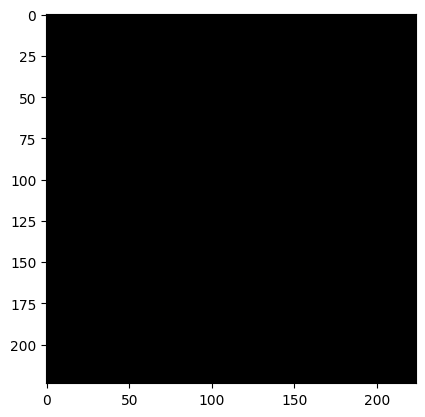

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(0)
plt.clf()
plt.imshow(results[2])
plt.show()

In [9]:
data_config = _config.get_config('trace_vla_moe')
dataset = LiberoTraceDataset(data_config.data.base_config, data_config.model.action_horizon)

def get_episode(episode_idx):
    start_idx = dataset.episode_starts[episode_idx]
    end_idx = dataset.episode_ends[episode_idx]
    data = dataset.hf_dataset[int(start_idx)]
    video_frames = []
    for i in range(start_idx, end_idx):
        img_data = dataset.hf_dataset[i]['image']
        video_frames.append(img_data)
    return video_frames

The dataset you requested (None) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=None
```

If you encounter a problem, contact LeRobot maintainers on [Discord](https://discord.com/invite/s3KuuzsPFb)
or open an [issue on GitHub](https://github.com/huggingface/lerobot/issues/new/choose).



Resolving data files:   0%|          | 0/4338 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/163 [00:00<?, ?it/s]

Using LiberoTraceDataset (TraceVLA)


In [32]:
video_data = get_episode(index)
visual = einops.rearrange(torch.tensor(video_data[0] * 255).float(), "c h w -> 1 1 c h w").to("cuda:0")
enc = model.encode(visual)
dec = model.decode_unroll(enc)
print(dec)

[[[[ 21  21  23]
   [ 22  22  23]
   [ 22  22  23]
   ...
   [146 141 133]
   [145 141 132]
   [145 141 132]]

  [[ 21  22  24]
   [ 21  22  23]
   [ 21  22  23]
   ...
   [147 142 133]
   [146 142 132]
   [146 143 133]]

  [[ 21  22  23]
   [ 21  22  23]
   [ 21  22  23]
   ...
   [146 142 133]
   [146 142 132]
   [146 142 132]]

  ...

  [[103  65  48]
   [103  65  49]
   [106  68  50]
   ...
   [ 92  55  36]
   [ 91  53  36]
   [ 92  55  36]]

  [[106  70  51]
   [104  67  49]
   [104  67  48]
   ...
   [ 90  52  34]
   [ 91  54  36]
   [ 91  55  36]]

  [[103  66  48]
   [102  65  48]
   [100  62  46]
   ...
   [ 86  49  33]
   [ 86  50  34]
   [ 88  52  35]]]]


/tmp/ipykernel_396421/2997437537.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  visual = einops.rearrange(torch.tensor(video_data[0] * 255).float(), "c h w -> 1 1 c h w").to("cuda:0")


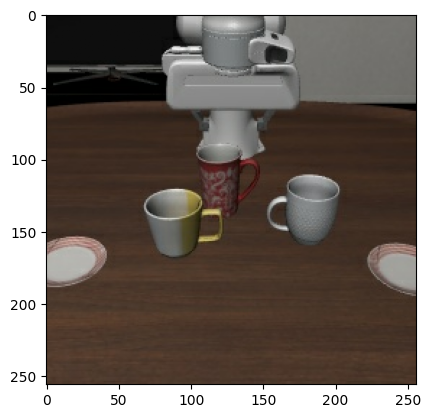

In [17]:
plt.figure(0)
plt.clf()
plt.imshow(einops.rearrange(video_data[0], "c h w -> h w c"))
plt.show()

In [25]:
model.model.heads['image_head'].model.decoder_embed.state_dict()

OrderedDict([('weight',
              tensor([[-0.0101, -0.0092, -0.0150,  ..., -0.0069, -0.0185, -0.0253],
                      [-0.0270,  0.0301,  0.0168,  ...,  0.0222,  0.0342, -0.0387],
                      [ 0.0016,  0.0273,  0.0077,  ...,  0.0084,  0.0077,  0.0767],
                      ...,
                      [-0.0267,  0.1851, -0.0422,  ...,  0.0203, -0.0183, -0.0138],
                      [ 0.0123, -0.0758, -0.0867,  ..., -0.0562,  0.0373,  0.0374],
                      [ 0.0677,  0.0910,  0.0387,  ..., -0.0215, -0.0034, -0.0445]],
                     device='cuda:0')),
             ('bias',
              tensor([ 0.0150,  0.0041, -0.0048,  ...,  0.0267,  0.0619,  0.0479],
                     device='cuda:0'))])